In [5]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/waico/SKAB/master/data/anomaly-free/anomaly-free.csv"
df = pd.read_csv(url, sep=';', index_col='datetime', parse_dates=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

Shape: (9405, 8)

Columns: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

First 5 rows:
                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
datetime                                                                       
2020-02-08 13:30:47           0.202394           0.275154  2.16975  0.382638   
2020-02-08 13:30:48           0.203153           0.277857  2.07999 -0.273216   
2020-02-08 13:30:50           0.202054           0.275790  2.52577  0.382638   
2020-02-08 13:30:51           0.203595           0.278101  2.49742  0.054711   
2020-02-08 13:30:52           0.201889           0.276363  2.29194  0.710565   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
datetime                                                                      
2020-02-08 13:30:47      90.6454       26.8508  238.852              122.664  
2020-02-08 13:30:48      90.7

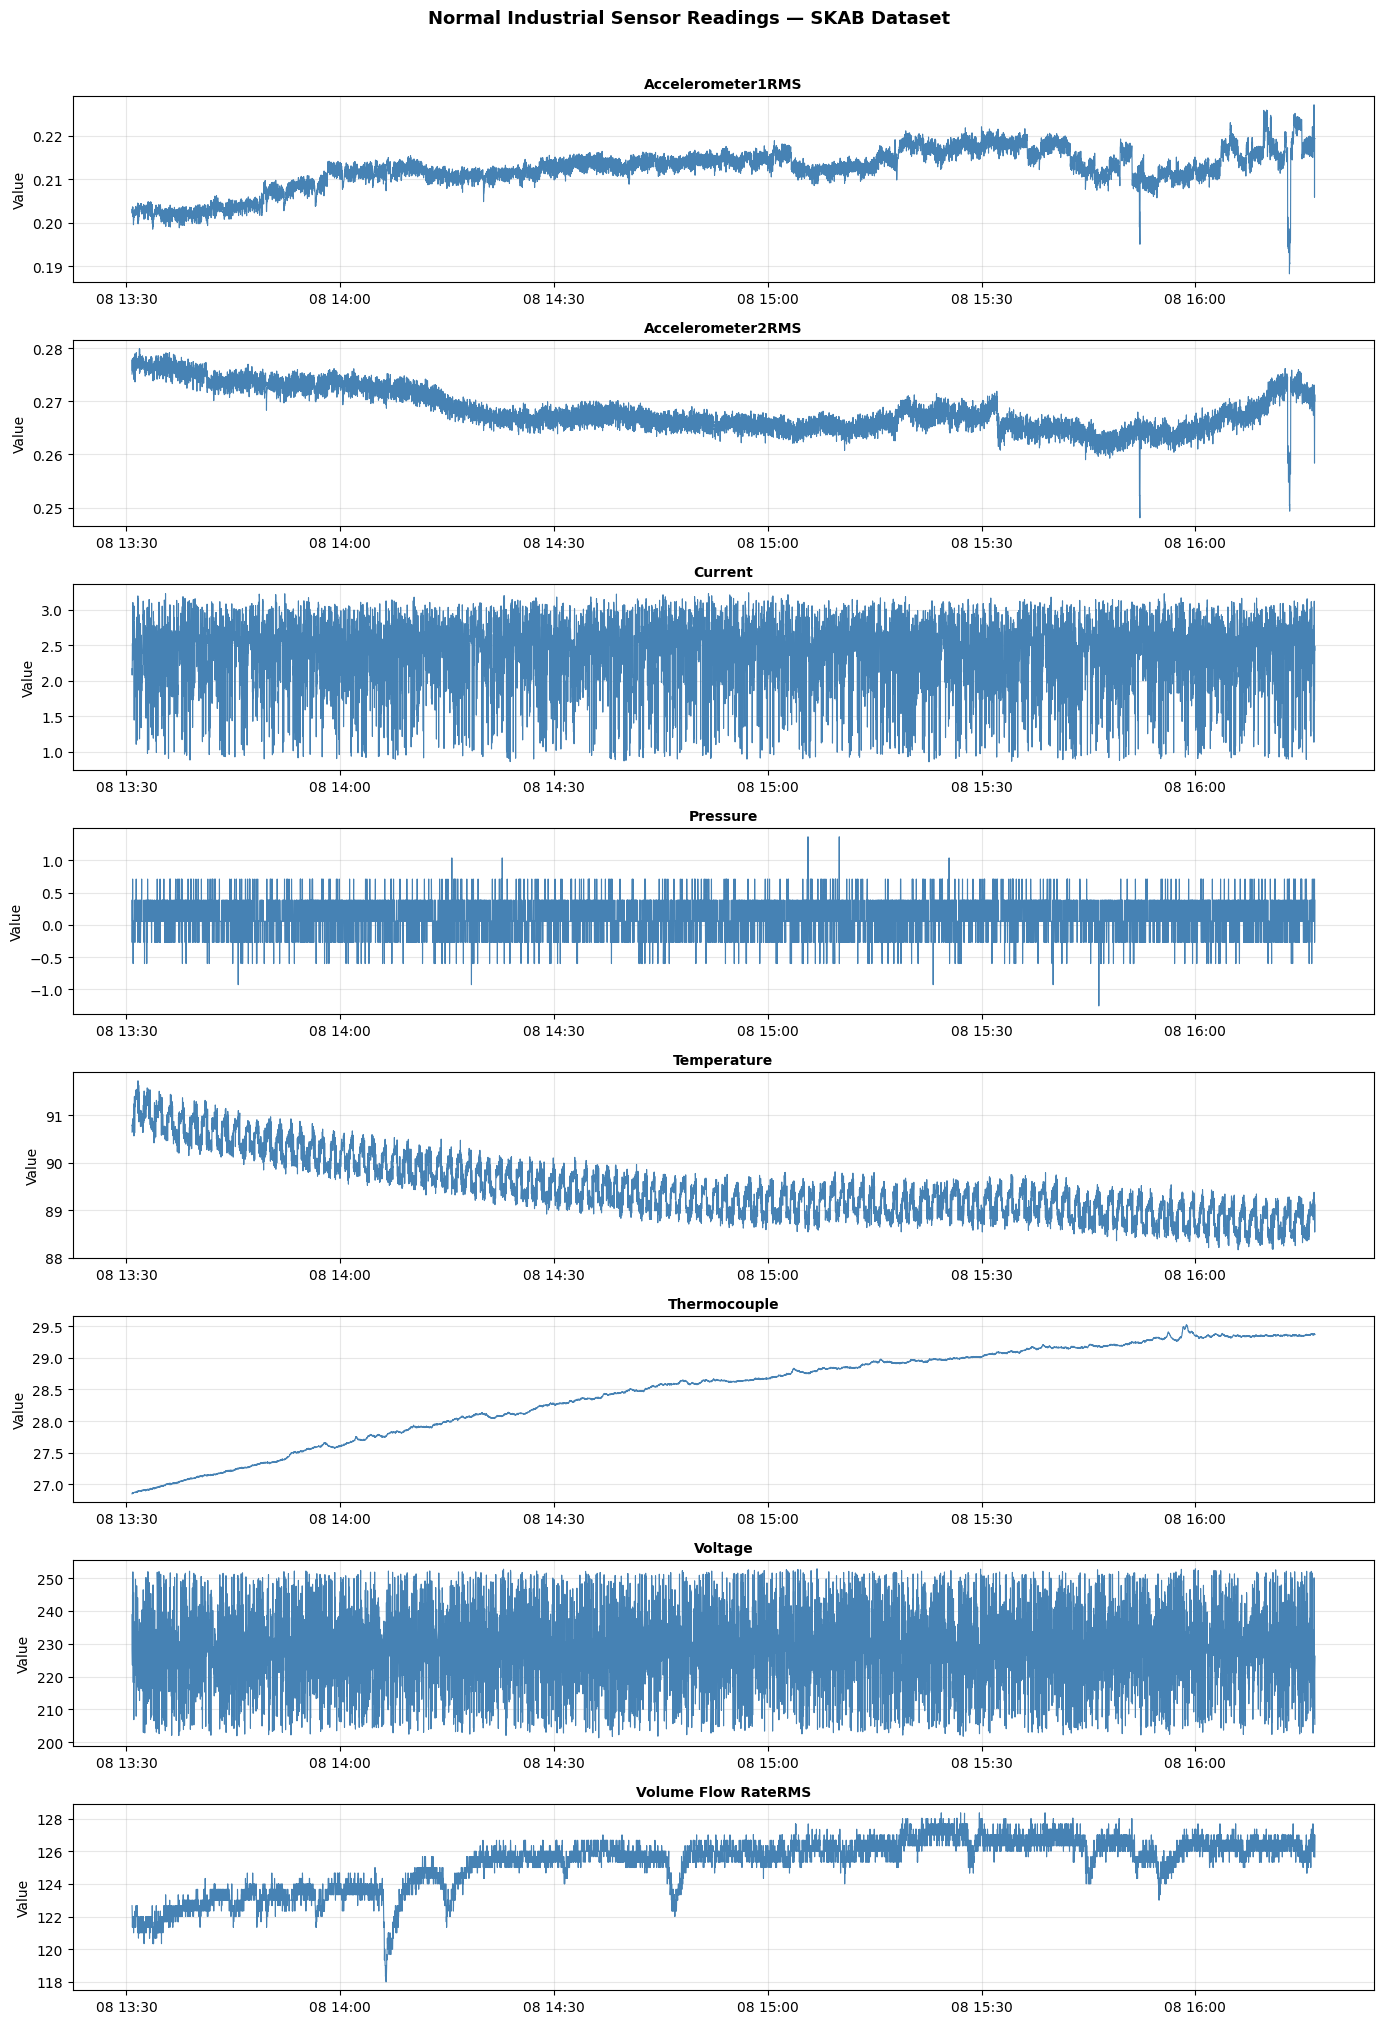

Chart saved to data/normal_sensors.png

This is what NORMAL looks like.
Study these patterns — tomorrow you add anomalies and your model learns to spot the difference.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 1, figsize=(14, 20))

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], linewidth=0.8, color='steelblue')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Normal Industrial Sensor Readings — SKAB Dataset', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/normal_sensors.png', dpi=100, bbox_inches='tight')
plt.show()

print("Chart saved to data/normal_sensors.png")
print("\nThis is what NORMAL looks like.")
print("Study these patterns — tomorrow you add anomalies and your model learns to spot the difference.")

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load one of the anomaly files from SKAB
anomaly_url = "https://raw.githubusercontent.com/waico/SKAB/master/data/valve1/1.csv"
df_anomaly = pd.read_csv(anomaly_url, sep=';', index_col='datetime', parse_dates=True)

print("Anomaly dataset shape:", df_anomaly.shape)
print("\nColumns:", df_anomaly.columns.tolist())
print("\nAnomaly labels distribution:")
print(df_anomaly['anomaly'].value_counts())
print("\nChangepoint labels:")
print(df_anomaly['changepoint'].value_counts())

Anomaly dataset shape: (1145, 10)

Columns: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']

Anomaly labels distribution:
anomaly
0.0    743
1.0    402
Name: count, dtype: int64

Changepoint labels:
changepoint
0.0    1141
1.0       4
Name: count, dtype: int64


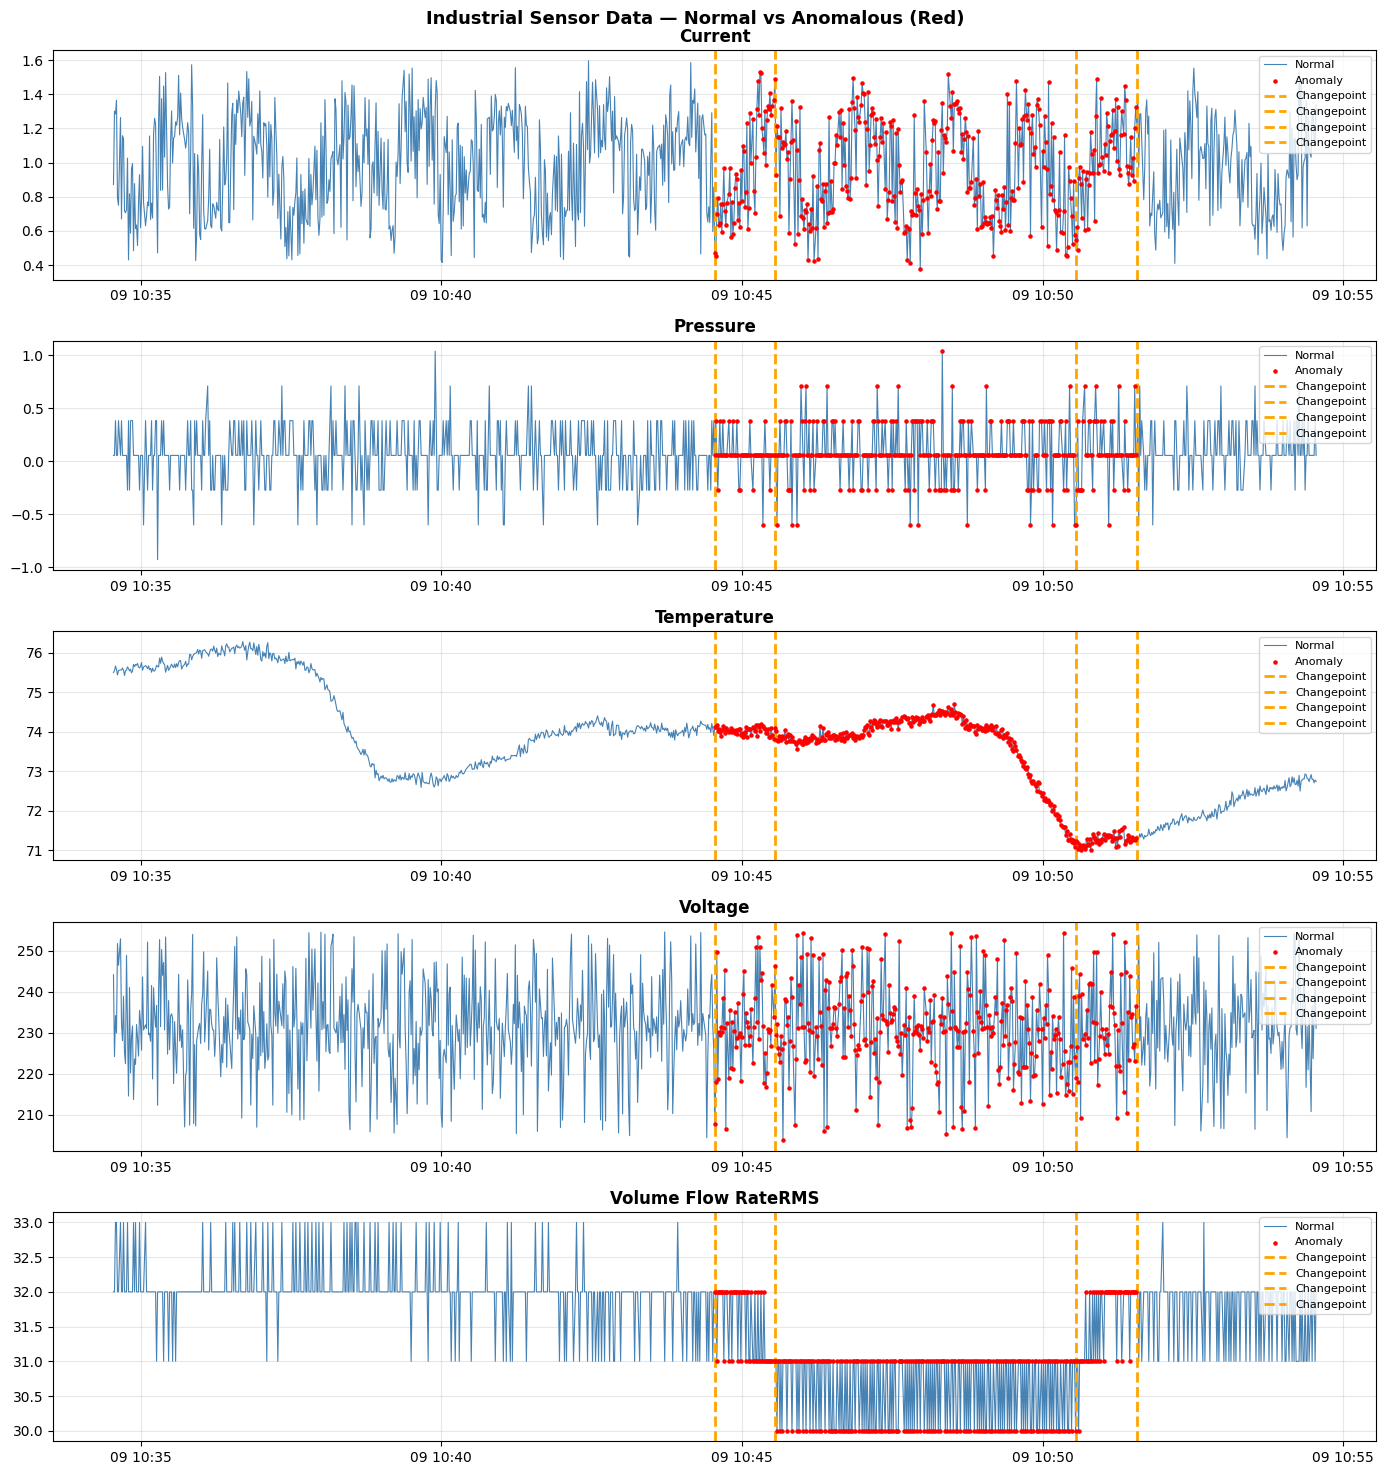

Saved to data/anomaly_visualisation.png


In [9]:
# Split into normal and anomalous
df_normal_section = df_anomaly[df_anomaly['anomaly'] == 0.0]
df_anomaly_section = df_anomaly[df_anomaly['anomaly'] == 1.0]

# Plot each sensor with anomalies highlighted in red
sensors = ['Current', 'Pressure', 'Temperature', 'Voltage', 'Volume Flow RateRMS']

fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 15))

for i, col in enumerate(sensors):
    # Plot all data in blue
    axes[i].plot(df_anomaly.index, df_anomaly[col], 
                 color='steelblue', linewidth=0.8, label='Normal')
    
    # Overlay anomalous periods in red
    anomaly_mask = df_anomaly['anomaly'] == 1.0
    axes[i].scatter(df_anomaly.index[anomaly_mask], 
                   df_anomaly[col][anomaly_mask],
                   color='red', s=5, label='Anomaly', zorder=5)
    
    # Mark changepoints with vertical lines
    changepoints = df_anomaly.index[df_anomaly['changepoint'] == 1.0]
    for cp in changepoints:
        axes[i].axvline(x=cp, color='orange', linewidth=2, 
                       linestyle='--', label='Changepoint')
    
    axes[i].set_title(col, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right', fontsize=8)

plt.suptitle('Industrial Sensor Data — Normal vs Anomalous (Red)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/anomaly_visualisation.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved to data/anomaly_visualisation.png")